# 04 — Retention Levers & Segmentation

Two things in this notebook:

1. How much do `is_auto_renew`, `payment_plan_days`, and `payment_method_id` associate with
   retention — with selection effects flagged explicitly, since users who opt into auto-renew
   or an annual plan are likely a different population from those who don't, independent of
   whatever the lever itself does.
2. Which subscriber segments carry the most **revenue risk**, sized so recommendations can be
   prioritized by dollars, not just by rate.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

sys.path.append(str(Path.cwd().parent))
from src import plotting

plotting.set_style()
periods = pd.read_parquet("../data/interim/periods.parquet")
members_cohort = pd.read_parquet("../data/interim/members_cohort.parquet")
resolved = periods[periods["outcome"] != "censored"]

### A note on leakage

Notebook 05 has to guard against using a transaction that's essentially the churn event itself
(e.g. the cancellation transaction) as a "predictor" of churn — that's a real leak there because
it joins each user's most recent transaction to a separate, later-determined label.

This notebook doesn't have that problem, and it's worth saying why rather than leaving it
implicit: every row here is a **period**, and a period's own `is_auto_renew` /
`payment_plan_days` / `payment_method_id` are set *when that period's transaction happened* —
strictly before the `renewed` outcome the row is being compared against, which depends on
whatever transaction (or lack of one) comes *after* it. There's no separate label being joined
after the fact; the feature and the outcome are already in the correct time order by
construction. The selection-effect caveats on each lever below are a real limitation — but they
are not a leakage problem.

## Lever 1: is_auto_renew

In [2]:
auto_renew_summary = resolved.groupby("is_auto_renew")["renewed"].agg(["mean", "size"])
print(auto_renew_summary)

table = pd.crosstab(resolved["is_auto_renew"], resolved["renewed"])
chi2, p, dof, _ = stats.chi2_contingency(table)
print(f"\nchi2 = {chi2:.1f}, p = {p:.4g}")

                   mean      size
is_auto_renew                    
0              0.687468   3191104
1              0.955719  18557195



chi2 = 2556371.6, p = 0


**Selection effect:** users who opt into auto-renew are plausibly more committed / less price-sensitive to begin with. Auto-renew doesn't just mechanically remove the "forgot to renew" failure mode — it also correlates with unobserved intent to stay. This association is not evidence that *flipping* auto-renew on for a given user would retain them at this rate.

## Lever 2: payment_plan_days

                       mean      size
payment_plan_days                    
0                  0.886997    872320
1                  0.873742      5069
7                  0.147272    581996
10                 0.585147     38510
14                 0.277003      6379
21                 0.325370       879
30                 0.942517  19138297
31                 0.976947    766609
35                 0.758539       849
45                 1.000000       550
60                 0.794528      9320
70                 0.756345       591
90                 0.899686     15601
100                0.673076     23871
120                0.822769     11375
180                0.806190     51984
195                0.724381    110845
200                0.683642      5832
240                0.857211      4195
360                0.735020      5691
395                0.812586     10853
400                0.770430      1860
410                0.718954     81378
450                0.634585      1278


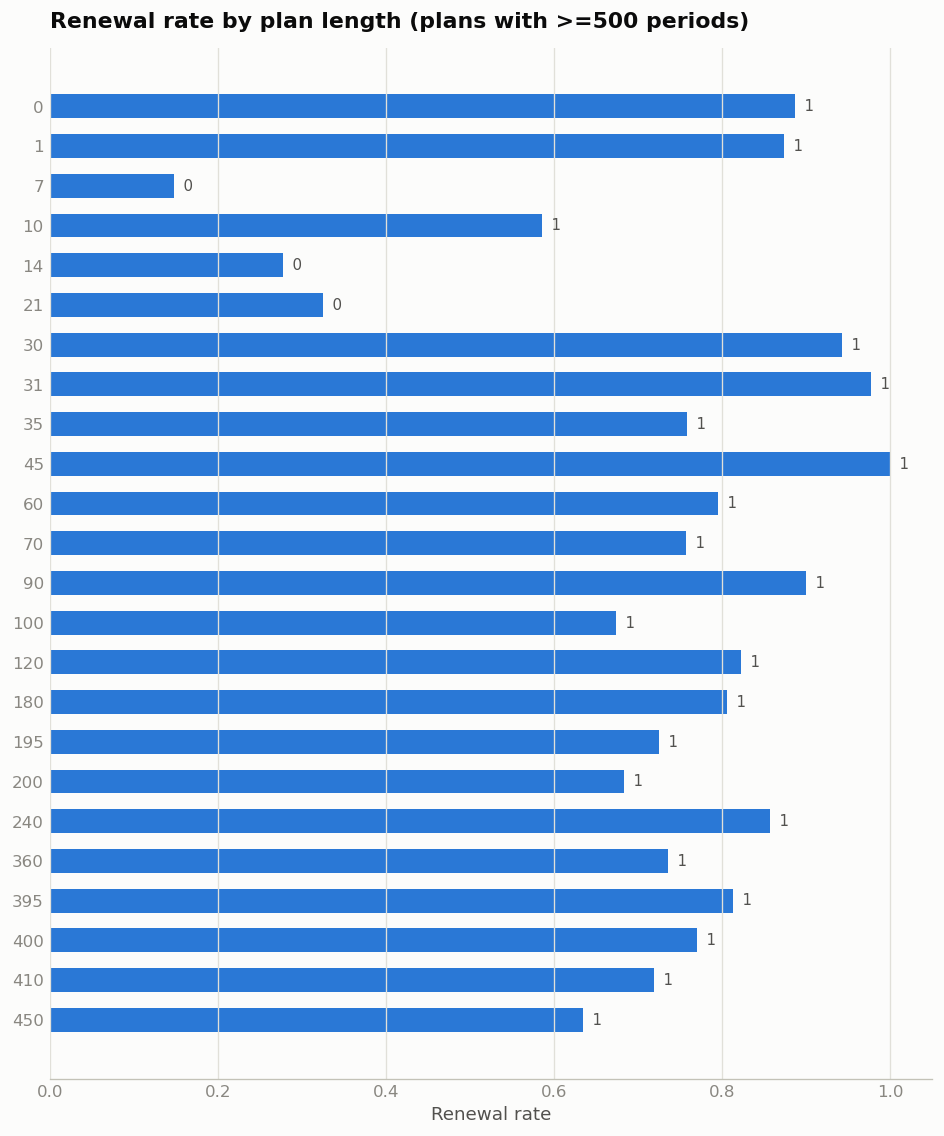

In [3]:
plan_days_summary = (
    resolved.groupby("payment_plan_days")["renewed"].agg(["mean", "size"])
    .query("size >= 500").sort_index()
)
print(plan_days_summary)

fig, ax = plotting.plot_segment_risk_bars(
    plan_days_summary.index.astype(str).tolist(),
    plan_days_summary["mean"].tolist(),
    "Renewal rate by plan length (plans with >=500 periods)",
    "Renewal rate",
    save_path="../figures/04_plan_days.png",
)

**Selection effect:** annual-plan subscribers already paid a large amount upfront and are a self-selected, likely lower-churn-propensity population — this is not evidence that moving a monthly subscriber onto an annual plan would produce the same retention rate for them.

### Is the 7-day plan's 14.7% "renewal rate" really a retention problem?

582K periods on a 7-day plan renew at only 14.7% — by far the worst of any plan length shown
above. Before treating that as "this paid product underperforms," check what users on this plan
are actually paying.

In [4]:
plan7 = resolved[resolved["payment_plan_days"] == 7]
print(plan7[["plan_list_price", "actual_amount_paid"]].describe())
print(f"\nactual_amount_paid == 0: {(plan7['actual_amount_paid'] == 0).mean():.2%} of periods")

       plan_list_price  actual_amount_paid
count    581996.000000       581996.000000
mean          0.459754            0.459754
std           3.984977            3.984977
min           0.000000            0.000000
25%           0.000000            0.000000
50%           0.000000            0.000000
75%           0.000000            0.000000
max          35.000000           35.000000

actual_amount_paid == 0: 98.69% of periods


**This is not a retention problem — it's a trial.** 98.7% of 7-day-plan periods are paid NT\$0.
This is KKBox's free trial mechanism, not an underperforming paid product, and its 14.7% figure
is a **trial-to-paid conversion rate**, not a renewal/retention rate — those are different
business metrics with different benchmarks and different levers. Renaming it doesn't change the
number, but confusing the two would send a "fix this failing product" recommendation at a
trial funnel that's actually just... a trial funnel. This finding also directly explains part of
the cohort-mix effect in notebook 02: cohorts with a higher trial share will show worse
aggregate "retention" even with no change in how well paying subscribers are retained.

## Lever 3: payment_method_id

In [5]:
method_summary = (
    resolved.groupby("payment_method_id")["renewed"].agg(["mean", "size"])
    .query("size >= 500").sort_values("mean", ascending=False)
)
print("Highest-retention methods:")
print(method_summary.head(10))
print("\nLowest-retention methods:")
print(method_summary.tail(10))

Highest-retention methods:
                       mean      size
payment_method_id                    
10                 0.982681      1328
11                 0.980778      2133
37                 0.972107   1009024
18                 0.966638     16216
40                 0.964388   2230023
41                 0.959472  11630892
27                 0.955420     62651
34                 0.939233    733427
19                 0.938655     32896
23                 0.937944     42929

Lowest-retention methods:
                       mean    size
payment_method_id                  
13                 0.761575    6652
32                 0.759704  148596
28                 0.715066   95538
22                 0.708296   19962
12                 0.699032    4027
20                 0.670049   27889
24                 0.625741   16200
8                  0.613601     647
7                  0.254362    1089
35                 0.125000  543607


Payment method carries selection too: some methods are disproportionately used by a particular subscriber type (e.g. auto-debit vs. convenience-store cash payment implies different banking access and possibly different income or commitment levels). Read these differences as descriptive segmentation, not as a lever to pull directly.

### Is payment method 35's 12.5% "renewal rate" the same trial-funnel story?

Method 35 is the worst-performing payment method shown above, on a large base (544K periods).
Same check as the plan-length case.

In [6]:
method35 = resolved[resolved["payment_method_id"] == 35]
print(method35[["plan_list_price", "actual_amount_paid", "payment_plan_days"]].describe())
print(f"\nactual_amount_paid == 0: {(method35['actual_amount_paid'] == 0).mean():.4%} of periods")
print(f"payment_plan_days == 7: {(method35['payment_plan_days'] == 7).mean():.4%} of periods")

       plan_list_price  actual_amount_paid  payment_plan_days
count    543607.000000       543607.000000      543607.000000
mean          0.000081            0.000083           7.000162
std           0.059677            0.061034           0.119355
min           0.000000            0.000000           7.000000
25%           0.000000            0.000000           7.000000
50%           0.000000            0.000000           7.000000
75%           0.000000            0.000000           7.000000
max          44.000000           45.000000          95.000000

actual_amount_paid == 0: 99.9998% of periods
payment_plan_days == 7: 99.9998% of periods


**Same finding, same conclusion.** Payment method 35 is, for practical purposes, the same
population as the 7-day free trial: 99.9998% of its transactions are on a 7-day plan, and
essentially 100% are paid NT\$0 (mean actual_amount_paid ≈ NT\$0.0001). It isn't really a
"payment method" carrying its own selection effect the way, say, credit card vs. convenience-store
cash does — it's the trial mechanism's internal bookkeeping code, and its 12.5% figure is the same
trial-to-paid conversion rate as the 7-day plan finding above, not a fourth, independent lever.

## Partial control: multivariate logistic regression
Puts the remaining levers in one model together, so each coefficient is "holding the others constant" rather than a raw marginal association. This partially addresses selection *between* the levers, but not the deeper selection into any of them versus unobserved subscriber intent.

In [7]:
price_days_corr = resolved[["plan_list_price", "payment_plan_days"]].corr().iloc[0, 1]
print(f"correlation(plan_list_price, payment_plan_days) = {price_days_corr:.4f}")

correlation(plan_list_price, payment_plan_days) = 0.9635


**`plan_list_price` is dropped from this regression.** At r=0.96 with `payment_plan_days`, a
coefficient on either one individually is not identifiable from the other — an earlier version
of this notebook kept both in with a caveat and got a `plan_list_price` coefficient of -11.6,
which is not a real effect size, just what an unstable, collinear fit happened to land on. A
caveat doesn't fix an uninterpretable number; dropping the redundant variable does.
`payment_plan_days` is kept as the plan-length control since it's the more directly interpretable
of the two (a duration, not a price point that's also correlated with plan tier for other
reasons). See the README's methodology section for this decision stated the same way.

In [8]:
top_methods = resolved["payment_method_id"].value_counts().head(8).index
reg_df = resolved[resolved["payment_method_id"].isin(top_methods)].copy()

X = pd.get_dummies(
    reg_df[["is_auto_renew", "payment_plan_days", "payment_method_id"]],
    columns=["payment_method_id"], drop_first=True,
)
X = sm.add_constant(X.astype(float))
y = reg_df["renewed"].astype(int)

lever_model = sm.Logit(y, X).fit(disp=False)
print(lever_model.summary())

                           Logit Regression Results                           
Dep. Variable:                renewed   No. Observations:             20243730
Model:                          Logit   Df Residuals:                 20243720
Method:                           MLE   Df Model:                            9
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                  0.2394
Time:                        23:20:24   Log-Likelihood:            -4.3099e+06
converged:                       True   LL-Null:                   -5.6663e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.6293      0.013     48.195      0.000       0.604       0.655
is_auto_renew            2.1163      0.012    174.947      0.000       2.093       2.140
payment_plan

## Segmentation: where's the revenue risk concentrated?
Segment by plan length x auto-renew, sized by resolved-period revenue and lapse rate — this ranking is what should drive prioritization in the README's recommendation memo.

In [9]:
resolved = resolved.copy()
resolved["plan_bucket"] = pd.cut(
    resolved["payment_plan_days"], bins=[0, 31, 100, 400], labels=["<=31d", "32-100d", "100d+"]
)
resolved["auto_renew_label"] = resolved["is_auto_renew"].map({0: "manual renew", 1: "auto-renew"})

segment = resolved.groupby(["plan_bucket", "auto_renew_label"], observed=True).agg(
    n_periods=("renewed", "size"),
    renewal_rate=("renewed", "mean"),
    revenue_at_stake=("actual_amount_paid", "sum"),
).reset_index()
segment["revenue_lost"] = segment["revenue_at_stake"] * (1 - segment["renewal_rate"])
segment = segment.sort_values("revenue_lost", ascending=False)
print(segment.to_string(index=False))

plan_bucket auto_renew_label  n_periods  renewal_rate  revenue_at_stake  revenue_lost
      <=31d     manual renew    2792897      0.677642         332128075  1.070643e+08
      <=31d       auto-renew   17744995      0.958541        2291240953  9.499156e+07
      100d+     manual renew     203647      0.758062         167530066  4.053193e+07
    32-100d     manual renew      51646      0.770108          20554614  4.725340e+06


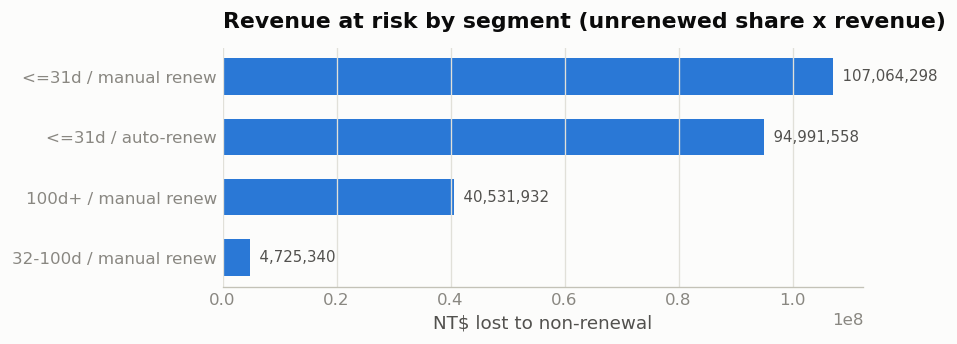

In [10]:
labels = (segment["plan_bucket"].astype(str) + " / " + segment["auto_renew_label"]).tolist()
fig, ax = plotting.plot_segment_risk_bars(
    labels, segment["revenue_lost"].tolist(),
    "Revenue at risk by segment (unrenewed share x revenue)", "NT$ lost to non-renewal",
    save_path="../figures/04_segment_risk.png",
)

## Demographic cut: city and age band
(carrying forward the `bd` data-quality caveat from notebook 01 — invalid ages get their own bucket rather than being dropped or guessed at).

In [11]:
demo = resolved.merge(
    members_cohort[["msno", "city", "bd", "gender"]], on="msno", how="left"
)
demo["age_valid"] = demo["bd"].between(10, 90)
demo["age_band"] = pd.cut(
    demo["bd"].where(demo["age_valid"]),
    bins=[10, 20, 30, 40, 50, 90], labels=["10-20", "20-30", "30-40", "40-50", "50+"],
)
demo["age_band"] = demo["age_band"].cat.add_categories(["unknown"]).fillna("unknown")

age_summary = demo.groupby("age_band", observed=True).agg(n=("renewed", "size"), renewal_rate=("renewed", "mean"))
print(age_summary)

top_cities = demo["city"].value_counts().head(10).index
city_summary = (
    demo[demo["city"].isin(top_cities)]
    .groupby("city").agg(n=("renewed", "size"), renewal_rate=("renewed", "mean"))
    .sort_values("renewal_rate")
)
print(city_summary)

                 n  renewal_rate
age_band                        
10-20       869598      0.852533
20-30      4901731      0.914803
30-40      2775213      0.924081
40-50       839047      0.922062
50+         326843      0.916419
unknown   12035867      0.919424


            n  renewal_rate
city                       
9.0    279027      0.874500
12.0   281525      0.905856
6.0    625350      0.911285
22.0  1031558      0.912751
15.0  1057596      0.914353
4.0   1192497      0.916755
5.0   1805469      0.918846
14.0   499485      0.919807
13.0  2469179      0.927793
1.0   8589184      0.930166


## Section summary

- Rank segments by `revenue_lost`, not by renewal rate alone — a small segment with a terrible
  renewal rate can matter less in dollar terms than a large segment with a mediocre one. That
  ranking is what should drive prioritization in the recommendation memo.
- Every lever association above is confounded by selection into that lever; none of them should
  be reported as "switching X would retain Y% of subscribers" without a controlled experiment.